In [2]:
import xarray as xr
import matplotlib.transforms as mtransforms
from cmcrameri import cm
from matplotlib import rc
from mpl_toolkits.axes_grid1 import ImageGrid

In [3]:
# load landcover and anette's landcover! (first normal landcover)
land_cover = xr.open_dataset('/mnt/data7/nfs4/avh_ndvi/sdupuis/ESACCI-LC-L4-LCCS-Map-300m-P1Y-2015-v2.0.7b.nc', engine='netcdf4')

In [4]:
lc = land_cover.sel(lat=slice(74,60), lon=slice(65,74))

In [5]:
std_anoms_day_al = xr.open_dataset('../anomaly_cubes/output_data/standard_anomalies_alaska_day.nc')

In [6]:
lc_interp = lc.interp(lat=std_anoms_day_al.coords['lat'], lon=std_anoms_day_al.coords['lon'], method='nearest')

In [7]:
subset = std_anoms_day_al.sel(lat=slice(60, 74), lon=slice(65,74))

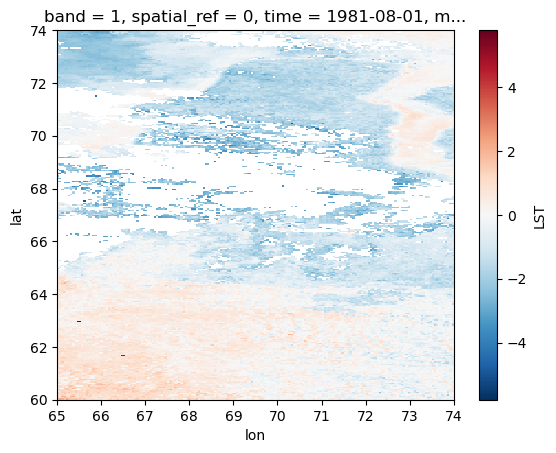

In [8]:
subset['LST'].isel(time=0).plot();

In [9]:
anoms_scfg = xr.open_dataset('output_data/standard_anoms_scfg.nc')

In [10]:
anoms_swe = xr.open_dataset('output_data/standard_anoms_swe.nc')

In [11]:
subset_swe = anoms_swe['swe'].sel(lat=slice(60, 74), lon=slice(65,74), time=slice('1981-08', '2018'))

In [12]:
subset_snow = anoms_scfg['scfg'].sel(lat=slice(60, 74), lon=slice(65,74))

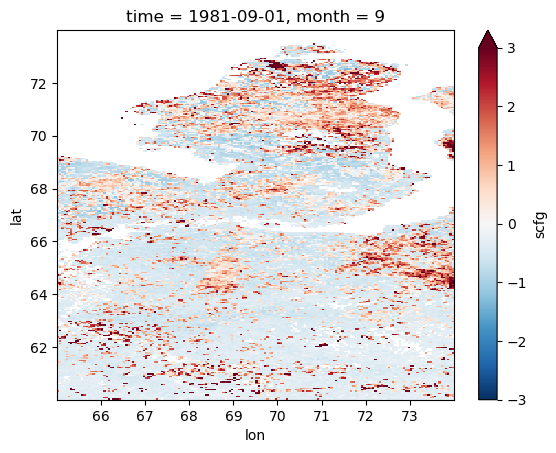

In [13]:
anoms_scfg['scfg'].sel(lat=slice(60, 74), lon=slice(65,74)).isel(time=1).plot(vmax=3);

In [14]:
subset_swe

<xarray.DataArray 'swe' (time: 449, lat: 140, lon: 90)>
[5657400 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 60.05 60.15 60.25 60.35 ... 73.65 73.75 73.85 73.95
  * lon      (lon) float64 65.05 65.15 65.25 65.35 ... 73.65 73.75 73.85 73.95
  * time     (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
    month    (time) int64 ...

In [15]:
#interp swe
anoms_swe_interp = subset_swe.interp(lat=subset.coords['lat'], lon=subset.coords['lon'], method='nearest')

In [16]:
anoms_swe_interp_aligned, da2 = xr.align(anoms_swe_interp, subset, join="inner")

In [17]:
anoms_swe_interp_aligned

<xarray.DataArray 'swe' (time: 446, lat: 280, lon: 180)>
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan, -0.1288655 , -0.06939776, ...,  0.36857509,
          0.32298883,         nan],
        [        nan, -0.06384067,  0.02846155, ...,  0.32601791,
          0.32777696,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * time         (time) datetime64[ns] 1981-08-01 1981-09-01 ... 2018-12-01
  * lat          (lat) float32 60.03 60.08 60.12 60.17 ... 73.88 73.93 73.97
  * lon          (lon) float32 65.03 65.07 65.12 65.18 ... 73.88 73.93 73.97
    month        (time) int64 8 9 10 11 12 1 2 3 4 5 ... 3 4 5 6 7 8 9 10 11 12
    band         int64 1
    spatial_ref  int64 0

In [18]:
swe_large_anoms = anoms_swe_interp_aligned.where((subset['LST'] > 1.0) & (subset['LST'] < 3.0))
swe_pos = swe_large_anoms.where(swe_large_anoms > 1)
swe_neg = swe_large_anoms.where(swe_large_anoms < -1)

In [19]:
swe_neg_season_count = (
    swe_neg
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)
swe_pos_season_count = (
    swe_pos
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)

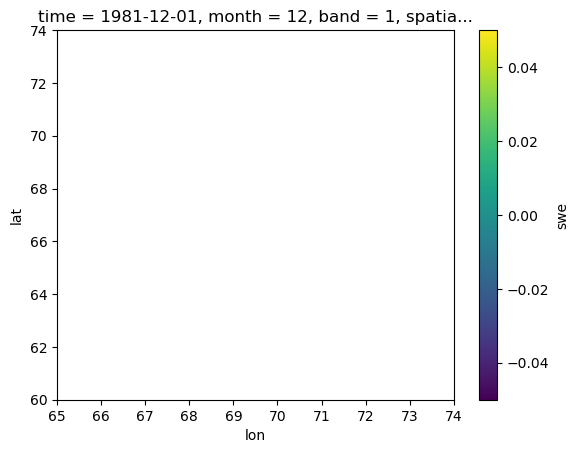

In [20]:
swe_pos.isel(time=4).plot();

In [21]:
snow_large_anoms = subset_snow.where((subset['LST'] > 1.0) & (subset['LST'] < 3.0))

In [22]:
snow_pos = snow_large_anoms.where(snow_large_anoms > 1)

In [23]:
snow_neg = snow_large_anoms.where(snow_large_anoms < -1)

In [24]:
snow_neg_season_count = (
    snow_neg
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)

In [25]:
snow_pos_season_count = (
    snow_pos
    .groupby("time.season")
    .count(dim="time")
).where(lc_interp['lccs_class'] != 210)


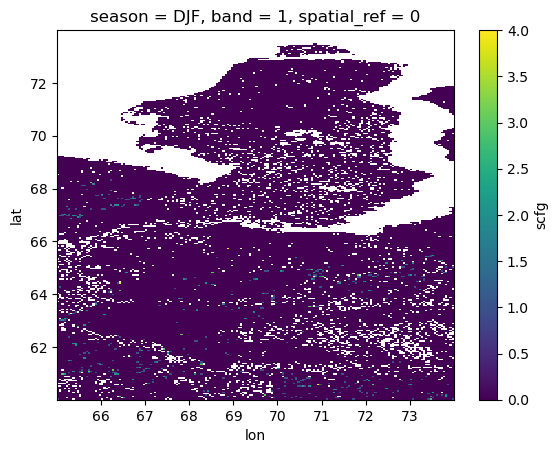

In [26]:
snow_pos_season_count.sel(season="DJF").plot();

In [27]:
snow_neg_season_count.sel(season="JJA").values

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

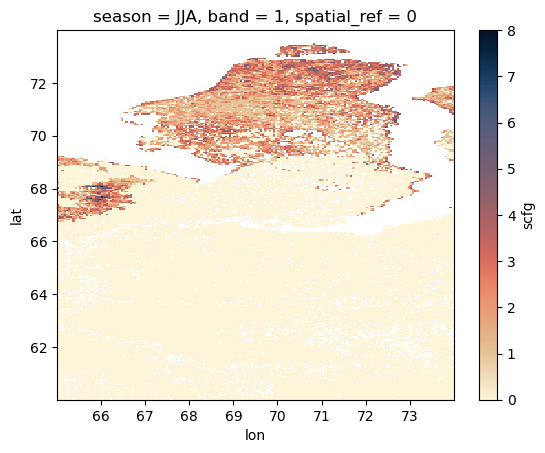

In [28]:
snow_neg_season_count.sel(season="JJA").plot(cmap=cm.lipari_r);

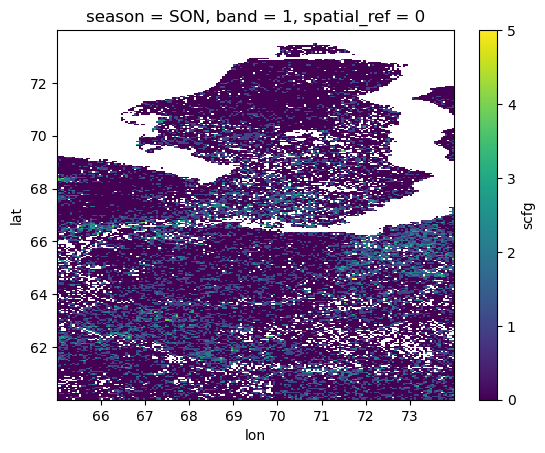

In [29]:
snow_pos_season_count.sel(season="SON").plot();

In [30]:
vmax = max(
    snow_neg_season_count.max(),
    snow_pos_season_count.max()
).item()

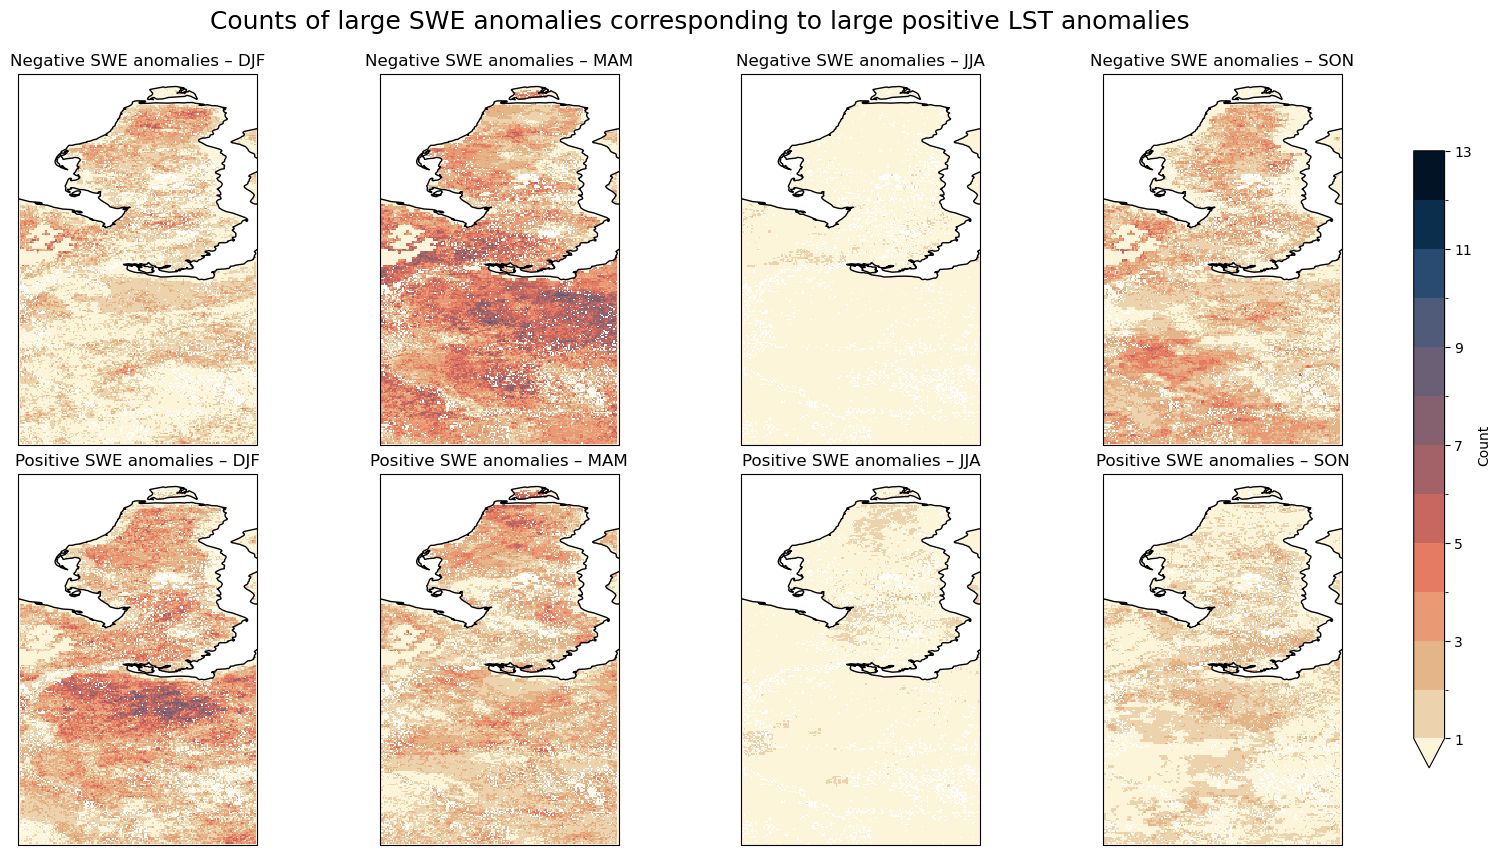

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(16, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# --- Row 1: negative snow anomalies ---
for i, season in enumerate(seasons):
    swe_neg_season_count.sel(season=season).plot(
        ax=axes[0, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=13
    )
    axes[0, i].set_title(f"Negative SWE anomalies – {season}")
    axes[0, i].coastlines()

# --- Row 2: positive snow anomalies ---
for i, season in enumerate(seasons):
    swe_pos_season_count.sel(season=season).plot(
        ax=axes[1, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=13
    )
    axes[1, i].set_title(f"Positive SWE anomalies – {season}")
    axes[1, i].coastlines()

# --- One shared colorbar (optional but recommended) ---



fig.suptitle(
    "Counts of large SWE anomalies corresponding to large positive LST anomalies",
    fontsize=18,
    y=1.05
)
#
cbar = fig.colorbar(
    axes[1, 0].collections[0],
    ax=axes,
    
    orientation="vertical",
    shrink=0.8,
    label="Count"
)
#plt.tight_layout()
plt.savefig('swe_yamal_2.png',dpi=300, bbox_inches="tight")

plt.show()


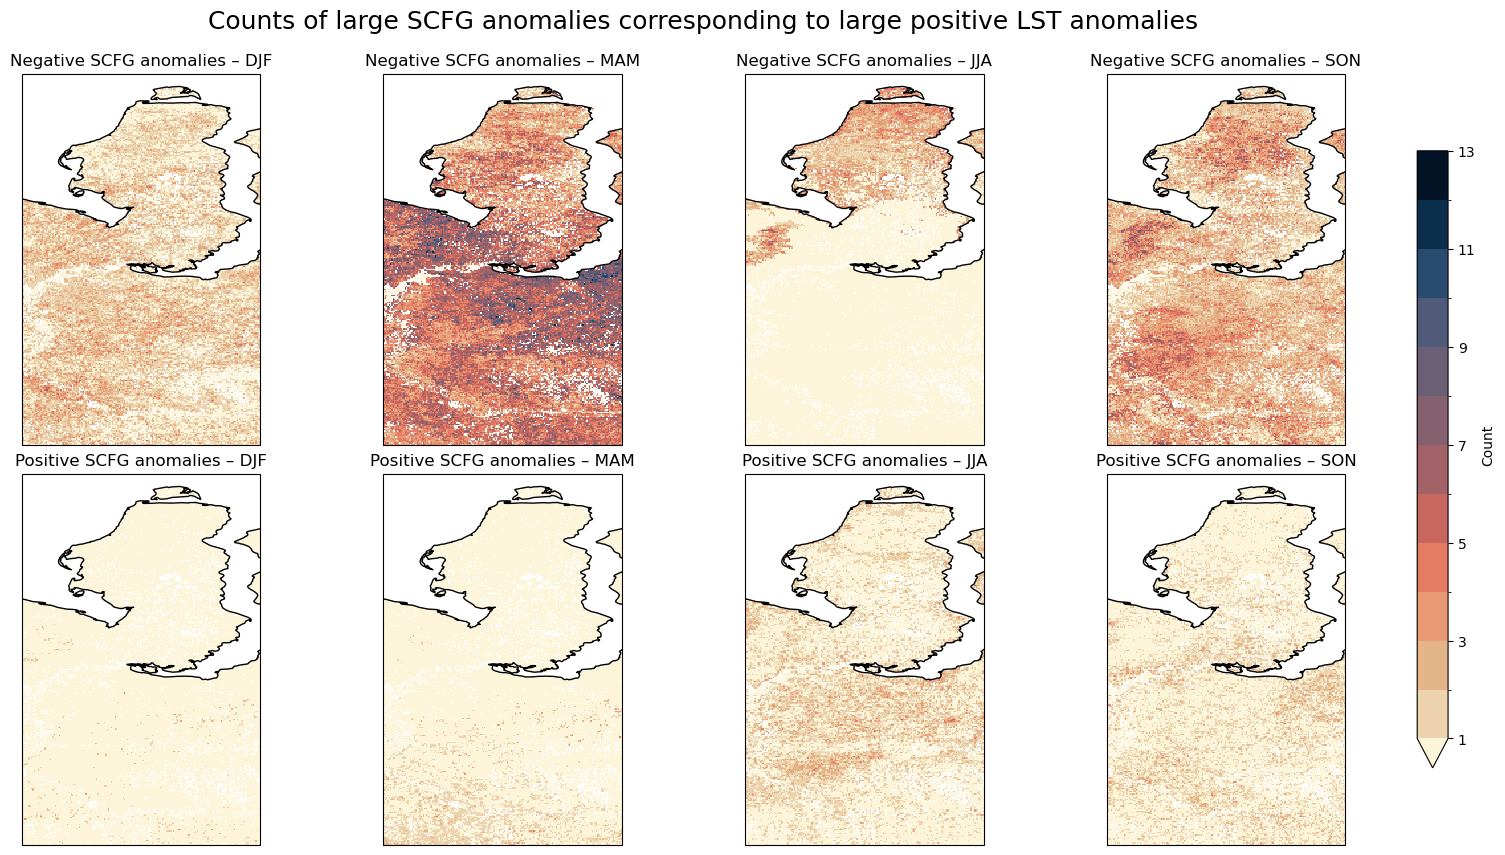

In [32]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

seasons = ["DJF", "MAM", "JJA", "SON"]

fig, axes = plt.subplots(
    nrows=2, ncols=4,
    figsize=(16, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# --- Row 1: negative snow anomalies ---
for i, season in enumerate(seasons):
    snow_neg_season_count.sel(season=season).plot(
        ax=axes[0, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=13
    )
    axes[0, i].set_title(f"Negative SCFG anomalies – {season}")
    axes[0, i].coastlines()

# --- Row 2: positive snow anomalies ---
for i, season in enumerate(seasons):
    snow_pos_season_count.sel(season=season).plot(
        ax=axes[1, i],
        transform=ccrs.PlateCarree(),
        add_colorbar=False, vmin=1, vmax=vmax, cmap=cm.lipari_r, levels=13
    )
    axes[1, i].set_title(f"Positive SCFG anomalies – {season}")
    axes[1, i].coastlines()

# --- One shared colorbar (optional but recommended) ---
cbar = fig.colorbar(
    axes[1, 0].collections[0],
    ax=axes,
    
    orientation="vertical",
    shrink=0.8,
    label="Count"
)


plt.suptitle(
    "Counts of large SCFG anomalies corresponding to large positive LST anomalies",
    fontsize=18,
    y=1.05
)

plt.savefig('snow_yamal.png',dpi=300, bbox_inches="tight")
plt.show()
